This notebook attempts to solve the following 2D pde with IC and BC:

\begin{equation}
\partial_t\rho = -v\partial_x \rho
\end{equation}

\begin{equation}
\left\{ \begin{aligned}
    \rho(0,t) = 1 \\ 
    \rho(x,0) = 0
\end{aligned}\right.
\end{equation}

semidiscrete weak form:

$$
\int(\partial_t\rho)qdx = \int v\rho(\partial_x q)dx-v\rho q\big|_{x=0}^1
$$
for now we ignore the boundary term on the RHS and discretize $\rho$ into time steps $n$ and spacial steps $j$:

$$
\rho^n = \sum_i \rho^{i,n}\psi^i
$$

and now if we change test function $q$ with $\psi^j$ we can substitute and use an implicit time scheme to get the full discrete form:

$$
\sum_i\left[
    \int\psi^i\psi^j\, dx - \Delta t v \int\psi^i(\partial_x\psi^j)dx
\right]\rho^{i,n+1} = \sum_i\int\psi^i\psi^jdx\rho^{i,n}
$$

which we can rewrite as:

$$
(M+\Delta t C) u^{n+1} = Mu^n \\
Au^{n+1}=Mu^n
$$

with
$$M_{ij}=\int \psi^i\psi^j dx,\\
C_{ij}=-\int v\psi^i(\partial_x\psi^j)dx\\
A_{ij}=M_{ij}+\Delta t C_{ij}$$

In [21]:
using Ferrite, SparseArrays, WriteVTK, Plots, LinearAlgebra

In [22]:
# Stop time, time step and velocity
dt = .01;
T = 1;
velocity = 1;

name = "constant_velocity_1d";

In [23]:
# generates 100 gridpoints between 
grid = generate_grid(Line, (100,), Vec((0.0,)), Vec((1.0,)))

# generate the same 
ip = Lagrange{RefLine, 1}()
qr = QuadratureRule{RefLine}(2)
fr = FacetQuadratureRule{RefLine}
cellvalues = CellValues(qr, ip)

# for the right boundary rest terms of our integration by parts
fqr = FacetQuadratureRule{RefLine}(1)
facetvalues = FacetValues(Float64, fqr, ip)
right = getfacetset(grid, "right")

OrderedCollections.OrderedSet{FacetIndex} with 1 element:
  FacetIndex((100, 2))

In [24]:
# degree of freedom handler, 
# our finished vector is (rho^1, rho^2, ... , rho^N)
dh = DofHandler(grid)
add!(dh, :rho, ip)
close!(dh);

In [25]:
# constraint handler
ch = ConstraintHandler(dh)
r_in = getfacetset(grid, "left")

dbc = Dirichlet(
    :rho,
    r_in,
    (x, t) -> 1.0
)
add!(ch, dbc)
close!(ch)
update!(ch, 0.0)

$$M_{ij}=\int \psi^i\psi^j dx$$

$$C_{ij}=-\int v\psi^i(\partial_x\psi^j)dx$$

In [26]:
function doassemble_C!(
    C::SparseMatrixCSC, 
    cellvalues::CellValues, 
    dh::DofHandler,
    facetvalues::FacetValues,
    grid::Grid
    )

    n_basefuncs = getnbasefunctions(cellvalues)
    Ce = zeros(n_basefuncs, n_basefuncs)

    assembler = start_assemble(C)

    for cell in CellIterator(dh)

        fill!(Ce, 0)
        reinit!(cellvalues, cell)

        for q_point in 1:getnquadpoints(cellvalues)
            dx = getdetJdV(cellvalues, q_point)

            for i in 1:n_basefuncs
                dpsi_i = shape_gradient(cellvalues, q_point, i)

                for j in 1:n_basefuncs
                    psi_j = shape_value(cellvalues, q_point, j)
                    # -v \psi^i(\partial_x\psi^j)dx
                    Ce[i, j] += -velocity * (dpsi_i ⋅ psi_j) * dx
                end
            end
        end

        assemble!(assembler, celldofs(cell), Ce)
    end

    # right-boundary term: -v rho q |_{x=1}
    for facet in FacetIterator(dh, right)
        fill!(Ce, 0)
        reinit!(facetvalues, facet)

        for q in 1:getnquadpoints(facetvalues)
            ddeltaomega = getdetJdV(facetvalues, q)

            for i in 1:n_basefuncs
                psi_i = shape_value(facetvalues, q, i)

                for j in 1:n_basefuncs
                    psi_j = shape_value(facetvalues, q, j)

                    Ce[i,j] += velocity * psi_j * psi_i * ddeltaomega
                end
            end
        end

        assemble!(assembler, celldofs(facet), Ce)
    end

    return C
end


doassemble_C! (generic function with 1 method)

In [27]:
function doassemble_M!(M::SparseMatrixCSC, cellvalues::CellValues, dh::DofHandler)

    # Allocate the element stiffness matrix
    n_basefuncs = getnbasefunctions(cellvalues)
    Me = zeros(n_basefuncs, n_basefuncs)

    # create an assembler
    assembler = start_assemble(M)

    for cell in CellIterator(dh)

        # per cell we take the local assembly matrix Me as zero
        fill!(Me, 0)

        # cellvalues contains tons and now it knows which cell we are looking at
        reinit!(cellvalues, cell)

        for q_point in 1:getnquadpoints(cellvalues)

            # not really dx but quadrature weight thingies
            dx = getdetJdV(cellvalues, q_point)

            for i in 1:n_basefuncs
                v = shape_value(cellvalues, q_point, i)
                for j in 1:n_basefuncs
                    u = shape_value(cellvalues, q_point, j)
                    Me[i, j] += (v * u) * dx
                end
            end
        end

        assemble!(assembler, celldofs(cell), Me)
    end
    return M
end

doassemble_M! (generic function with 1 method)

In [28]:
C = allocate_matrix(dh);
M = allocate_matrix(dh);

C = doassemble_C!(C, cellvalues, dh, facetvalues, grid)
M = doassemble_M!(M, cellvalues, dh)
A = (dt .* C) + M;

In [29]:
rho_n = zeros(ndofs(dh));
apply!(rho_n, ch)

rhsdata = get_rhs_data(ch, A);
apply!(A, ch);


In [30]:
# for error analysis
nsteps = Int(round(T / dt));
rho_all = zeros(ndofs(dh), nsteps);

In [31]:
pvd = paraview_collection(joinpath(name, name))

VTKGridFile(joinpath(name, name), dh) do vtk
    write_solution(vtk, dh, rho_n)
    pvd[0.0] = vtk
end

A_fr = lu(A)
for (step, t) in enumerate(dt:dt:T)
    #First of all, we need to update the Dirichlet boundary condition values.
    # does not really do anything since the boundary condition is independent of time?
    update!(ch, t)

    #Secondly, we compute the right-hand-side of the problem.
    b = M * rho_n
    #Then, we can apply the boundary conditions of the current time step.
    apply_rhs!(rhsdata, b, ch)

    #Finally, we can solve the time step and save the solution afterwards.
    rho = A_fr \ b
    apply!(rho, ch) 

    VTKGridFile(joinpath(name, "$(name)-$step"), dh) do vtk
        write_solution(vtk, dh, rho)
        pvd[t] = vtk
    end
    #At the end of the time loop, we set the previous solution to the current one and go to the next time step.
    rho_n .= rho
    rho_all[:, step] .= rho
    
    # # debug
    # if (step == 1)
    #     println(rho[100])
    # end
end

In [32]:
vtk_save(pvd);

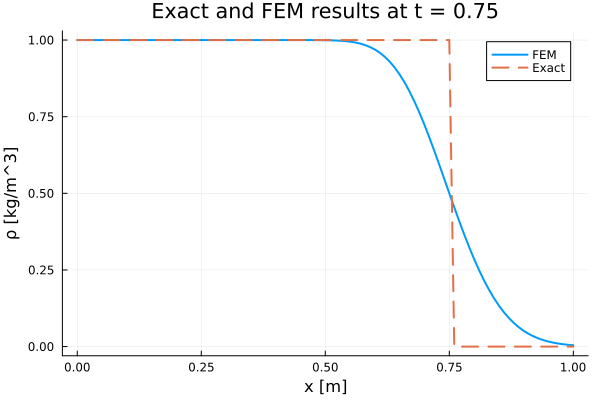

In [50]:
timestep = 75;

function rho_exact(x, t)
    if x - velocity * t > 0
        return 0
    end
    return 1
end

# x-coordinates
x = [get_node_coordinate(node)[1] for node in grid.nodes];
dx = x[2] - x[1];

# values this timestep
t = dt * timestep;
rho50 = rho_all[:, timestep];
rho_exact_vals = [rho_exact(xi, t) for xi in x];

# plot
plot(x, rho50, label = "FEM", lw = 2, title = "Exact and FEM results at t = $t")
plot!(x, rho_exact_vals, label = "Exact", lw = 2, linestyle = :dash)
xlabel!("x [m]")
ylabel!("ρ [kg/m^3]")

In [34]:
errors = zeros(nsteps)

dx = x[2] - x[1]

for step in 1:nsteps
    t = step * dt

    rho_num = rho_all[:, step]
    rho_ex  = [rho_exact(xi, t) for xi in x]

    errors[step] = sqrt(sum((rho_num .- rho_ex).^2) * dx)
end

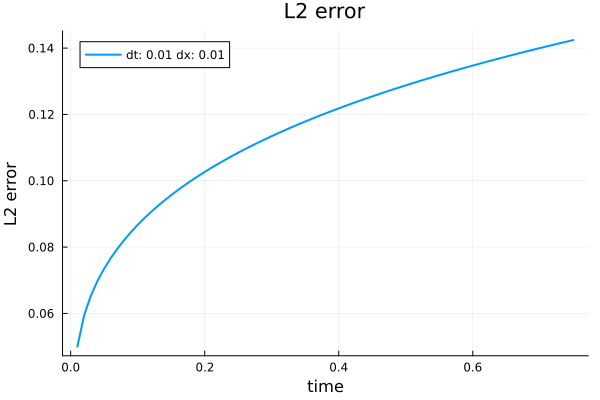

In [35]:
nplot = Int(floor(0.75 * length(errors)))

times = collect(dt:dt:nplot*dt)

plot(times, errors[1:nplot],
     xlabel = "time",
     ylabel = "L2 error",
     lw = 2,
     label = "dt: $dt dx: $dx",
     title = "L2 error")

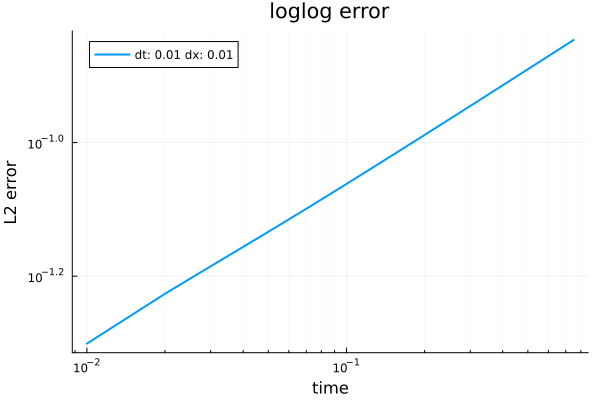

In [36]:
plot(times, errors[1:nplot],
     xlabel = "time",
     ylabel = "L2 error",
     lw = 2,
     label = "dt: $dt dx: $dx",
     title = "loglog error")

plot!(xscale=:log10, yscale=:log10, minorgrid=true)

In [45]:
velocity = 1;
T = 1;

function calc_error(
    dt::Float64,
    nx::Int64
)   
    nsteps = Int(round(T / (2*dt)));

    # generates 100 gridpoints between 
    grid = generate_grid(Line, (nx,), Vec((0.0,)), Vec((1.0,)))

    # generate the same 
    ip = Lagrange{RefLine, 1}()
    qr = QuadratureRule{RefLine}(2)
    fr = FacetQuadratureRule{RefLine}
    cellvalues = CellValues(qr, ip)

    # for the right boundary rest terms of our integration by parts
    fqr = FacetQuadratureRule{RefLine}(1)
    facetvalues = FacetValues(Float64, fqr, ip)
    right = getfacetset(grid, "right")

    # degree of freedom handler, 
    # our finished vector is (rho^1, rho^2, ... , rho^N)
    dh = DofHandler(grid)
    add!(dh, :rho, ip)
    close!(dh);

    # constraint handler
    ch = ConstraintHandler(dh)
    r_in = getfacetset(grid, "left")

    dbc = Dirichlet(
        :rho,
        r_in,
        (x, t) -> 1.0
    )
    add!(ch, dbc)
    close!(ch)
    update!(ch, 0.0)

    function doassemble_C!(
        C::SparseMatrixCSC, 
        cellvalues::CellValues, 
        dh::DofHandler,
        facetvalues::FacetValues,
        grid::Grid
        )

        n_basefuncs = getnbasefunctions(cellvalues)
        Ce = zeros(n_basefuncs, n_basefuncs)

        assembler = start_assemble(C)

        for cell in CellIterator(dh)

            fill!(Ce, 0)
            reinit!(cellvalues, cell)

            for q_point in 1:getnquadpoints(cellvalues)
                dx = getdetJdV(cellvalues, q_point)

                for i in 1:n_basefuncs
                    dpsi_i = shape_gradient(cellvalues, q_point, i)

                    for j in 1:n_basefuncs
                        psi_j = shape_value(cellvalues, q_point, j)
                        # -v \psi^i(\partial_x\psi^j)dx
                        Ce[i, j] += -velocity * (dpsi_i ⋅ psi_j) * dx
                    end
                end
            end

            assemble!(assembler, celldofs(cell), Ce)
        end

        # right-boundary term: -v rho q |_{x=1}
        for facet in FacetIterator(dh, right)
            fill!(Ce, 0)
            reinit!(facetvalues, facet)

            for q in 1:getnquadpoints(facetvalues)
                ddeltaomega = getdetJdV(facetvalues, q)

                for i in 1:n_basefuncs
                    psi_i = shape_value(facetvalues, q, i)

                    for j in 1:n_basefuncs
                        psi_j = shape_value(facetvalues, q, j)

                        Ce[i,j] += velocity * psi_j * psi_i * ddeltaomega
                    end
                end
            end

            assemble!(assembler, celldofs(facet), Ce)
        end

        return C
    end


    # generate matrices
    C = allocate_matrix(dh);
    M = allocate_matrix(dh);

    C = doassemble_C!(C, cellvalues, dh, facetvalues, grid)
    M = doassemble_M!(M, cellvalues, dh)
    A = (dt .* C) + M;

    rho_n = zeros(ndofs(dh));
    apply!(rho_n, ch)

    rhsdata = get_rhs_data(ch, A);
    apply!(A, ch);

    A_fr = lu(A)
    for step in (1:nsteps)

        # t
        t = step*dt

        #First of all, we need to update the Dirichlet boundary condition values.
        # does not really do anything since the boundary condition is independent of time?
        update!(ch, t)

        #Secondly, we compute the right-hand-side of the problem.
        b = M * rho_n
        #Then, we can apply the boundary conditions of the current time step.
        apply_rhs!(rhsdata, b, ch)

        #Finally, we can solve the time step and save the solution afterwards.
        rho = A_fr \ b
        apply!(rho, ch) 

        #At the end of the time loop, we set the previous solution to the current one and go to the next time step.
        rho_n .= rho
    end


    function rho_exact(x, t)
        if x - velocity * t > 0
            return 0
        end
        return 1
    end

    # x-coordinates
    x = [get_node_coordinate(node)[1] for node in grid.nodes];
    dx = x[2] - x[1];

    # values this timestep
    t = dt * nsteps;

    # rho exact
    rho_ex  = [rho_exact(xi, t) for xi in x]
    error = sqrt(sum((rho_n .- rho_ex).^2) * dx)

    return error
end

calc_error (generic function with 1 method)

In [46]:
dts = [0.1, 0.05, 0.025, 0.0125, 0.00625]
nxs = [10, 20, 40, 80, 160]

errors = zeros(length(dts))

for i in eachindex(dts)
    errors[i] = calc_error(dts[i], nxs[i])
end

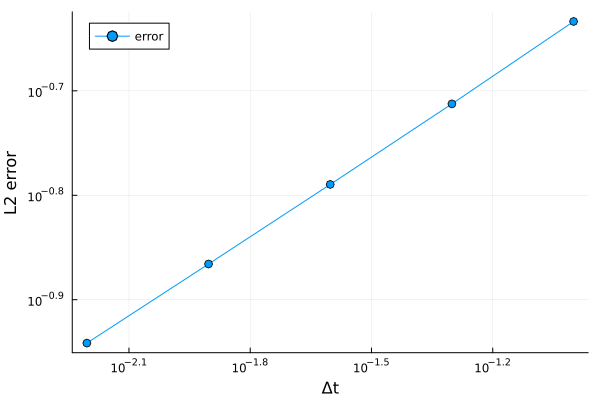

In [47]:
plot(dts, errors,
     xscale = :log10,
     yscale = :log10,
     marker = :o,
     xlabel = "Δt",
     ylabel = "L2 error",
     label = "error")

In [48]:
orders = [
    log(errors[i]/errors[i+1]) / log(dts[i]/dts[i+1])
    for i in 1:length(errors)-1
]

println(orders)

[0.2620940349885939, 0.25618244190173517, 0.2530891203483331, 0.25153048604316625]
